# NAIP Inference — Walmart Parking Lot Occupancy

Runs the fine-tuned ResNet34 U-Net segmentation model on all images in `Data/naip_images`.

**Output** → `Data/naip_occupancy_results.csv` with columns:

| Column | Description |
|---|---|
| `store_id` | Integer extracted from the filename prefix (e.g. `34` from `34_2019-07-01.png`) |
| `date` | ISO date string extracted from the filename (e.g. `2019-07-01`) |
| `year` | Integer year derived from `date` |
| `occupancy` | Fraction of detected parking pixels that are occupied (0–1) |

**Analysis** (Section 3):
- Average occupancy per year
- Number of images per year

## 1 · Setup

In [1]:
import re
from pathlib import Path

import albumentations as A
import numpy as np
import pandas as pd
import torch
from albumentations.pytorch import ToTensorV2
from PIL import Image
import segmentation_models_pytorch as smp

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_ROOT      = Path("../Data")
NAIP_DIR       = DATA_ROOT / "naip_images"
CHECKPOINT_DIR = Path("../checkpoints")
OUTPUT_CSV     = DATA_ROOT / "naip_occupancy_results.csv"

FT_CKPT   = CHECKPOINT_DIR / "resnet34_unet_walmart_ft.pth"
BASE_CKPT = CHECKPOINT_DIR / "resnet34_unet_best.pth"
CKPT_PATH = FT_CKPT if FT_CKPT.exists() else BASE_CKPT

# ── Model config (must match training) ────────────────────────────────────
IN_CHANNELS = 3
NUM_CLASSES = 3
IMG_SIZE    = 256

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

ckpt_label = "fine-tuned" if CKPT_PATH == FT_CKPT else "base PKLot (fine-tuned not found)"
print(f"Device     : {DEVICE}")
print(f"Checkpoint : {CKPT_PATH}  ({ckpt_label})")
print(f"Images dir : {NAIP_DIR.resolve()}")

Device     : mps
Checkpoint : ../checkpoints/resnet34_unet_walmart_ft.pth  (fine-tuned)
Images dir : /Users/felipe/Documents/BSE/Term-3/Deeplearning/Application-of-Deep-learning-image/Data/naip_images


In [2]:
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = None,
    in_channels     = IN_CHANNELS,
    classes         = NUM_CLASSES,
    activation      = None,
)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print(f"Model loaded from {CKPT_PATH.name}, eval mode on {DEVICE}")

Model loaded from resnet34_unet_walmart_ft.pth, eval mode on mps


## 2 · Discover & Parse Images

Filename format: `{store_id}_{YYYY-MM-DD}.png`  
- `store_id` = integer before the first underscore  
- `date`     = ISO date string after the first underscore

In [3]:
all_paths = sorted(NAIP_DIR.glob("*.png"))
print(f"Found {len(all_paths)} PNG files in {NAIP_DIR}\n")

records = []
skipped = []
for p in all_paths:
    m = re.match(r"^(\d+)_(\d{4}-\d{2}-\d{2})", p.stem)
    if m:
        records.append({"path": p, "store_id": int(m.group(1)), "date": m.group(2)})
    else:
        skipped.append(p.name)

print(f"Parsed successfully : {len(records)}")
if skipped:
    print(f"Skipped (no match)  : {skipped}")

# Preview first few
for r in records[:5]:
    print(f"  store={r['store_id']:>5}  date={r['date']}  file={r['path'].name}")

Found 559 PNG files in ../Data/naip_images

Parsed successfully : 559
  store= 1042  date=2011-08-15  file=1042_2011-08-15.png
  store= 1042  date=2013-09-27  file=1042_2013-09-27.png
  store= 1042  date=2015-08-04  file=1042_2015-08-04.png
  store= 1042  date=2017-09-09  file=1042_2017-09-09.png
  store= 1042  date=2019-11-02  file=1042_2019-11-02.png


## 2 · Run Inference

For each image:
1. Resize to 256×256, normalise with ImageNet stats
2. Run the model (argmax over class logits)
3. Compute **occupancy** = `occupied_pixels / (empty_pixels + occupied_pixels)`

Class indices: `0` = background, `1` = space-empty, `2` = space-occupied.

In [4]:
preprocess = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

def run_inference(path: Path) -> float:
    """Return occupancy rate (0–1) for a single image."""
    img     = np.array(Image.open(path).convert("RGB"))
    resized = np.array(Image.fromarray(img).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    tensor  = preprocess(image=resized)["image"].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).squeeze(0).cpu().numpy()  # (256, 256)

    empty    = int((pred == 1).sum())
    occupied = int((pred == 2).sum())
    parking  = empty + occupied
    return occupied / parking if parking > 0 else 0.0


rows = []
n    = len(records)
print(f"Running inference on {n} images …")

for i, rec in enumerate(records, 1):
    occ = run_inference(rec["path"])
    rows.append({"store_id": rec["store_id"], "date": rec["date"], "occupancy": occ})
    if i % 50 == 0 or i == n:
        print(f"  [{i:>3}/{n}] last: store={rec['store_id']}  {rec['date']}  occ={occ:.3f}")

print("\nDone.")

Running inference on 559 images …
  [ 50/559] last: store=1530  2017-07-02  occ=0.700
  [100/559] last: store=1903  2021-11-06  occ=0.269
  [150/559] last: store=2424  2023-05-25  occ=0.388
  [200/559] last: store=2728  2022-07-11  occ=0.684
  [250/559] last: store=3047  2021-11-13  occ=0.463
  [300/559] last: store=3276  2012-07-13  occ=0.225
  [350/559] last: store=3551  2022-04-30  occ=0.307
  [400/559] last: store=380  2021-11-16  occ=0.139
  [450/559] last: store=4132  2010-07-27  occ=0.896
  [500/559] last: store=528  2010-08-29  occ=0.264
  [550/559] last: store=874  2023-07-29  occ=0.303
  [559/559] last: store=938  2023-07-30  occ=0.062

Done.


In [5]:
df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

# Save
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows → {OUTPUT_CSV.resolve()}\n")
df.head(10)

Saved 559 rows → /Users/felipe/Documents/BSE/Term-3/Deeplearning/Application-of-Deep-learning-image/Data/naip_occupancy_results.csv



,store_id,date,occupancy,year
0,42,2012-06-22,0.366626,2012
1,42,2015-08-20,0.176388,2015
2,42,2023-06-06,0.082311,2023
3,111,2012-06-25,0.343926,2012
4,111,2014-07-05,0.270779,2014
5,111,2018-11-28,0.096028,2018
6,111,2021-10-18,0.187573,2021
7,111,2023-08-26,0.221353,2023
8,115,2010-08-09,0.367880,2010
9,115,2013-08-07,0.130514,2013


## 3 · Analysis

### 3a · Average Occupancy per Year

Mean occupancy rate across all stores and images grouped by calendar year.

Average occupancy per year

  Year    Mean occ       Std   N images
────────────────────────────────────────
  2010       43.8%     18.0%         45
  2011       41.2%     19.6%         37
  2012       37.7%     17.9%         35
  2013       33.3%     20.9%         44
  2014       34.3%     20.2%         32
  2015       35.3%     19.7%         40
  2016       31.8%     17.3%         34
  2017       38.6%     21.6%         38
  2018       32.4%     16.9%         44
  2019       39.8%     18.0%         32
  2020       30.5%     15.0%         27
  2021       36.5%     17.2%         48
  2022       41.7%     22.1%         40
  2023       26.5%     15.9%         63


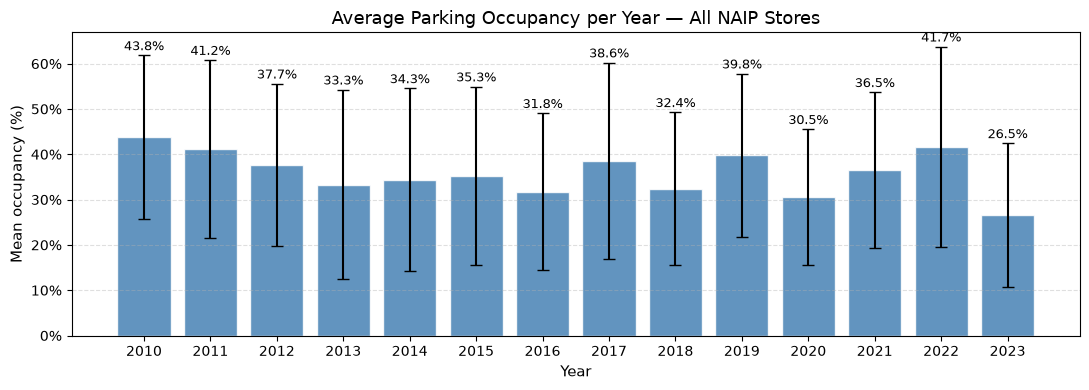

In [6]:
import matplotlib.pyplot as plt

avg_occ = (
    df.groupby("year")["occupancy"]
    .agg(mean_occupancy="mean", std_occupancy="std", n_images="count")
    .reset_index()
)
avg_occ["mean_pct"] = avg_occ["mean_occupancy"] * 100
avg_occ["std_pct"]  = avg_occ["std_occupancy"]  * 100

print("Average occupancy per year\n")
print(f"{'Year':>6}  {'Mean occ':>10}  {'Std':>8}  {'N images':>9}")
print("─" * 40)
for _, row in avg_occ.iterrows():
    print(f"{int(row.year):>6}  {row.mean_pct:>9.1f}%  {row.std_pct:>7.1f}%  {int(row.n_images):>9}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(avg_occ["year"], avg_occ["mean_pct"],
       yerr=avg_occ["std_pct"], capsize=4,
       color="steelblue", edgecolor="white", alpha=0.85)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean occupancy (%)", fontsize=11)
ax.set_title("Average Parking Occupancy per Year — All NAIP Stores", fontsize=13)
ax.set_xticks(avg_occ["year"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
for x, y in zip(avg_occ["year"], avg_occ["mean_pct"]):
    ax.text(x, y + avg_occ.loc[avg_occ.year == x, "std_pct"].values[0] + 0.5,
            f"{y:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 3b · Number of Images per Year

Number of images per year

  Year   N images
────────────────────
  2010         45
  2011         37
  2012         35
  2013         44
  2014         32
  2015         40
  2016         34
  2017         38
  2018         44
  2019         32
  2020         27
  2021         48
  2022         40
  2023         63
 Total        559


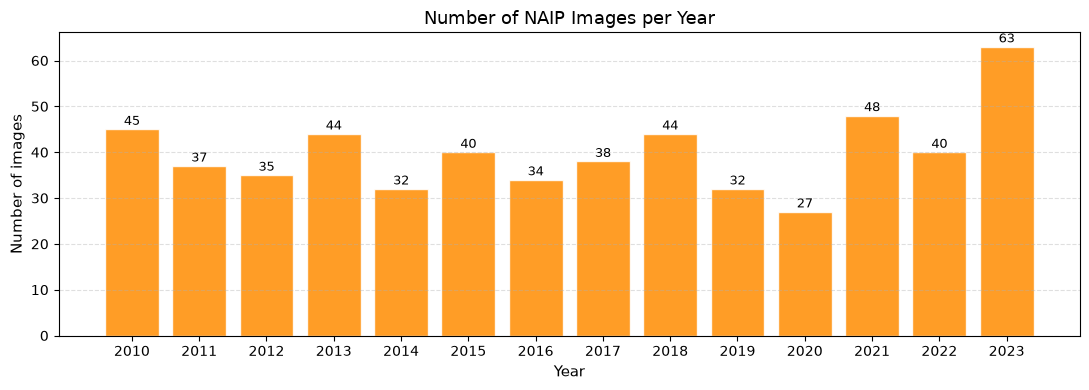

In [7]:
img_count = df.groupby("year").size().reset_index(name="n_images")

print("Number of images per year\n")
print(f"{'Year':>6}  {'N images':>9}")
print("─" * 20)
for _, row in img_count.iterrows():
    print(f"{int(row.year):>6}  {int(row.n_images):>9}")
print(f"{'Total':>6}  {img_count.n_images.sum():>9}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(img_count["year"], img_count["n_images"],
       color="darkorange", edgecolor="white", alpha=0.85)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of images", fontsize=11)
ax.set_title("Number of NAIP Images per Year", fontsize=13)
ax.set_xticks(img_count["year"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y)}"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
for x, y in zip(img_count["year"], img_count["n_images"]):
    ax.text(x, y + 0.3, str(int(y)), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### 3c · Occupancy Variation Within the Same Store (Year-over-Year)

For each store with data in at least two different years, we compute the **year-over-year change in occupancy**:

`Δ occupancy = occ(year_t) − occ(year_t−1)`

When a store has more than one image in a given year, the yearly occupancy is the mean of those images before computing the delta.

The chart shows the **mean signed change** averaged across all stores that have consecutive data for a given year pair, revealing years with systematic increases or drops in parking occupancy.

Year-over-year transitions computed: 442
Stores with ≥2 years of data       : 95

  Year    Mean Δ occ    Mean |Δ|   N stores
──────────────────────────────────────────────
  2011       -15.5%       15.5%          5
  2012        -2.9%        8.9%         27
  2013        -5.7%       19.5%         32
  2014        -5.7%       11.4%         27
  2015        -1.1%       15.9%         38
  2016        -3.3%       12.4%         32
  2017  +       3.5%       11.9%         37
  2018  +       0.4%       14.9%         42
  2019        -3.4%        9.0%         31
  2020        -4.0%       11.6%         27
  2021  +       2.8%       14.3%         47
  2022  +       7.7%       15.8%         36
  2023        -8.9%       14.5%         61


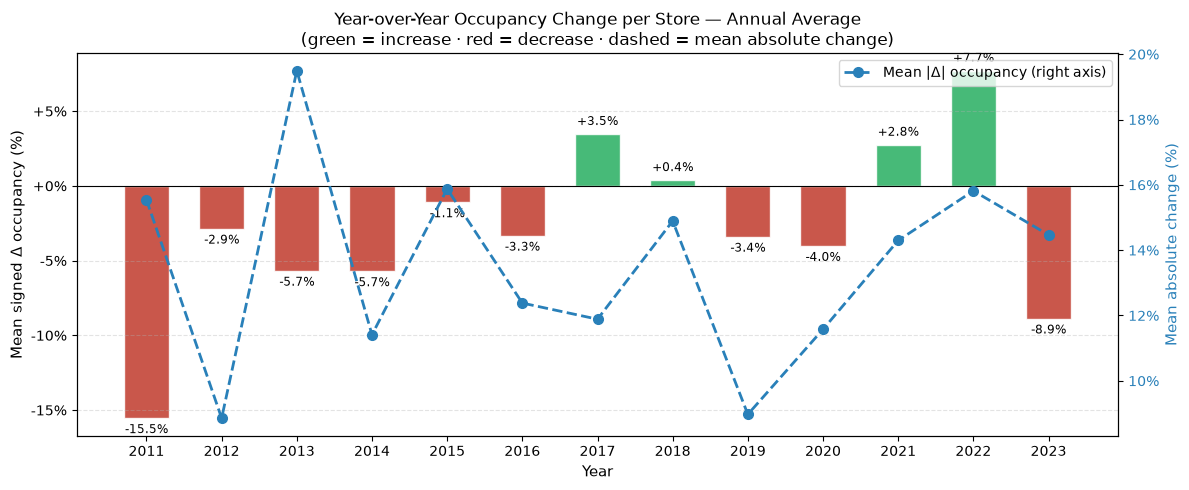

In [8]:
# Step 1 — mean occupancy per (store, year)
store_yearly = (
    df.groupby(["store_id", "year"])["occupancy"]
    .mean()
    .reset_index()
    .sort_values(["store_id", "year"])
)

# Step 2 — year-over-year delta per store (only consecutive years that actually exist in the data)
delta_rows = []
for store_id, grp in store_yearly.groupby("store_id"):
    grp = grp.sort_values("year")
    if len(grp) < 2:
        continue
    for (_, prev), (_, curr) in zip(grp.iloc[:-1].iterrows(), grp.iloc[1:].iterrows()):
        delta_rows.append({
            "store_id"  : store_id,
            "year_from" : int(prev["year"]),
            "year_to"   : int(curr["year"]),
            "delta"     : curr["occupancy"] - prev["occupancy"],
            "abs_delta" : abs(curr["occupancy"] - prev["occupancy"]),
        })

deltas = pd.DataFrame(delta_rows)
print(f"Year-over-year transitions computed: {len(deltas)}")
print(f"Stores with ≥2 years of data       : {deltas['store_id'].nunique()}\n")

# Step 3 — average delta per target year
yearly_variation = (
    deltas.groupby("year_to")
    .agg(
        mean_delta     = ("delta",     "mean"),
        mean_abs_delta = ("abs_delta", "mean"),
        n_stores       = ("store_id",  "count"),
    )
    .reset_index()
)
yearly_variation["mean_delta_pct"]     = yearly_variation["mean_delta"]     * 100
yearly_variation["mean_abs_delta_pct"] = yearly_variation["mean_abs_delta"] * 100

# ── Table ───────────────────────────────────────────────────────────────────
print(f"{'Year':>6}  {'Mean Δ occ':>12}  {'Mean |Δ|':>10}  {'N stores':>9}")
print("─" * 46)
for _, row in yearly_variation.iterrows():
    sign = "+" if row.mean_delta_pct >= 0 else ""
    print(f"{int(row.year_to):>6}  {sign}{row.mean_delta_pct:>10.1f}%  "
          f"{row.mean_abs_delta_pct:>9.1f}%  {int(row.n_stores):>9}")

# ── Chart ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

years   = yearly_variation["year_to"]
deltas_ = yearly_variation["mean_delta_pct"]
colors  = ["#c0392b" if d < 0 else "#27ae60" for d in deltas_]

bars = ax.bar(years, deltas_, color=colors, edgecolor="white", alpha=0.85, width=0.6)

# mean absolute variation as an overlay line
ax2 = ax.twinx()
ax2.plot(years, yearly_variation["mean_abs_delta_pct"],
         color="#2980b9", marker="o", linewidth=2, markersize=7,
         linestyle="--", label="Mean |Δ| occupancy (right axis)")
ax2.set_ylabel("Mean absolute change (%)", fontsize=11, color="#2980b9")
ax2.tick_params(axis="y", labelcolor="#2980b9")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean signed Δ occupancy (%)", fontsize=11)
ax.set_title(
    "Year-over-Year Occupancy Change per Store — Annual Average\n"
    "(green = increase · red = decrease · dashed = mean absolute change)",
    fontsize=12
)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.0f}%"))
ax.grid(axis="y", linestyle="--", alpha=0.35)

for x, y in zip(years, deltas_):
    va  = "bottom" if y >= 0 else "top"
    off = 0.4 if y >= 0 else -0.4
    ax.text(x, y + off, f"{y:+.1f}%", ha="center", va=va, fontsize=8.5)

ax2.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()

---

## Part II · Filtered Store Analysis (P20–P80 of Occupancy Variation)

Stores with extreme **occupancy variation** (std dev across years below P20 or above P80) are removed. This strips out stores that barely change over time (always flat) and stores that swing wildly, keeping only those with a "typical" amount of variation.

After filtering, each store is classified as **growing** or **decreasing** based on the slope of a linear fit of its occupancy over time.

Results shown:
1. Store distribution of variation before / after filtering
2. Average occupancy per year — filtered stores only
3. Average occupancy per year split by trend (growing vs decreasing)

P20 variation threshold : 0.0712  (7.12 pp)
P80 variation threshold : 0.1559  (15.59 pp)
Stores with ≥2 images   : 95
Stores kept (P20–P80)   : 57
Stores removed          : 38
Images kept             : 338 / 559


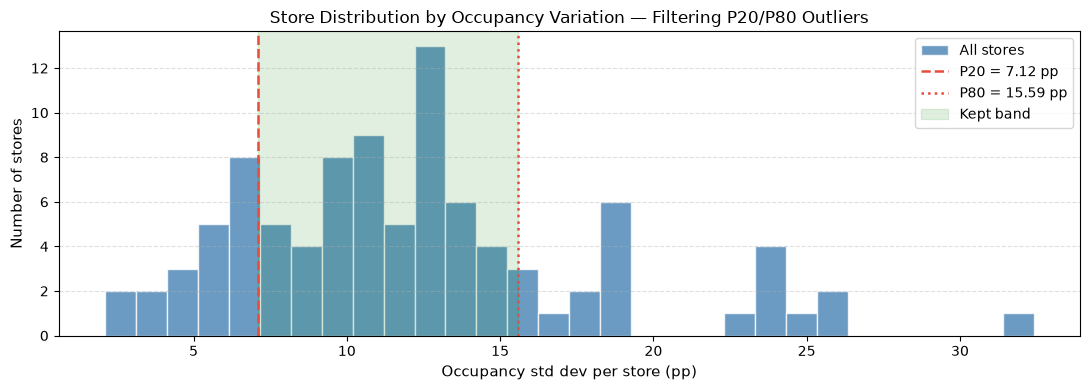

In [9]:
# ── Per-store occupancy variation (std dev across years) ───────────────────
# Only stores with ≥2 observations can have a meaningful std dev
store_std = (
    df.groupby("store_id")["occupancy"]
    .std()
    .dropna()                          # drops stores with a single image
    .rename("occ_std")
)

p20 = store_std.quantile(0.20)
p80 = store_std.quantile(0.80)

stores_filtered = store_std[(store_std >= p20) & (store_std <= p80)].index
df_ii = df[df["store_id"].isin(stores_filtered)].copy()

print(f"P20 variation threshold : {p20:.4f}  ({p20*100:.2f} pp)")
print(f"P80 variation threshold : {p80:.4f}  ({p80*100:.2f} pp)")
print(f"Stores with ≥2 images   : {len(store_std)}")
print(f"Stores kept (P20–P80)   : {len(stores_filtered)}")
print(f"Stores removed          : {len(store_std) - len(stores_filtered)}")
print(f"Images kept             : {len(df_ii)} / {len(df)}")

# ── Distribution plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(store_std * 100, bins=30, color="steelblue", edgecolor="white", alpha=0.8, label="All stores")
ax.axvline(p20 * 100, color="#e74c3c", linewidth=1.8, linestyle="--", label=f"P20 = {p20*100:.2f} pp")
ax.axvline(p80 * 100, color="#e74c3c", linewidth=1.8, linestyle=":",  label=f"P80 = {p80*100:.2f} pp")
ax.axvspan(p20 * 100, p80 * 100, alpha=0.12, color="green", label="Kept band")
ax.set_xlabel("Occupancy std dev per store (pp)", fontsize=11)
ax.set_ylabel("Number of stores", fontsize=11)
ax.set_title("Store Distribution by Occupancy Variation — Filtering P20/P80 Outliers", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [10]:
# ── Classify each filtered store as growing or decreasing ──────────────────
# Linear slope fitted over (year, occupancy) for each store.
# Slope > 0 → growing, slope < 0 → decreasing.

store_trends = {}
for store_id, grp in df_ii.groupby("store_id"):
    grp = grp.sort_values("year")
    if len(grp) < 2:
        continue
    slope = np.polyfit(grp["year"], grp["occupancy"], deg=1)[0]
    store_trends[store_id] = "growing" if slope >= 0 else "decreasing"

trend_series = pd.Series(store_trends, name="trend")
df_ii = df_ii.join(trend_series, on="store_id")

n_grow = (trend_series == "growing").sum()
n_dec  = (trend_series == "decreasing").sum()
print(f"Filtered stores classified:")
print(f"  Growing    : {n_grow}")
print(f"  Decreasing : {n_dec}")
print(f"  Total      : {n_grow + n_dec}")

Filtered stores classified:
  Growing    : 18
  Decreasing : 39
  Total      : 57



All filtered
  Year    Mean occ       Std
──────────────────────────────
  2010       48.3%     14.7%
  2011       40.5%     18.5%
  2012       43.7%     12.2%
  2013       33.6%     18.6%
  2014       36.9%     18.7%
  2015       36.6%     18.5%
  2016       33.5%     15.9%
  2017       37.5%     22.8%
  2018       32.8%     15.2%
  2019       42.6%     17.4%
  2020       32.9%     13.0%
  2021       35.3%     14.9%
  2022       38.7%     19.5%
  2023       28.3%     15.5%

Growing
  Year    Mean occ       Std
──────────────────────────────
  2010       56.5%     12.7%
  2011       31.5%     16.1%
  2012       47.7%     23.5%
  2013       26.6%     19.8%
  2014       34.8%     16.0%
  2015       39.2%     24.0%
  2016       40.4%     15.9%
  2017       53.7%     29.5%
  2018       36.3%     15.7%
  2019       51.3%     12.9%
  2020       39.6%     13.3%
  2021       43.5%     16.5%
  2022       53.4%     20.9%
  2023       32.9%     16.4%

Decreasing
  Year    Mean occ       Std
────

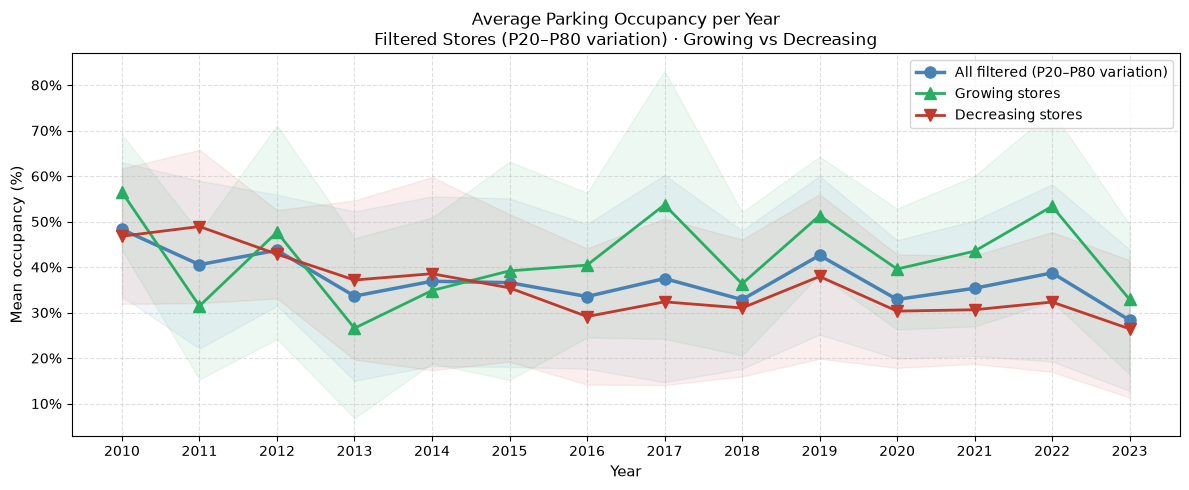

In [11]:
# ── Average occupancy per year — filtered stores (all), growing, decreasing ─
def yearly_avg(frame):
    g = frame.groupby("year")["occupancy"].agg(mean="mean", std="std").reset_index()
    g["mean_pct"] = g["mean"] * 100
    g["std_pct"]  = g["std"]  * 100
    return g

avg_all  = yearly_avg(df_ii)
avg_grow = yearly_avg(df_ii[df_ii["trend"] == "growing"])
avg_dec  = yearly_avg(df_ii[df_ii["trend"] == "decreasing"])

# ── Print tables ────────────────────────────────────────────────────────────
for label, tbl in [("All filtered", avg_all), ("Growing", avg_grow), ("Decreasing", avg_dec)]:
    print(f"\n{label}\n{'Year':>6}  {'Mean occ':>10}  {'Std':>8}")
    print("─" * 30)
    for _, row in tbl.iterrows():
        print(f"{int(row.year):>6}  {row.mean_pct:>9.1f}%  {row.std_pct:>7.1f}%")

# ── Chart: three lines on one plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

cfg = [
    (avg_all,  "All filtered (P20–P80 variation)", "steelblue",  "o",  2.5),
    (avg_grow, "Growing stores",                   "#27ae60",    "^",  2.0),
    (avg_dec,  "Decreasing stores",                "#c0392b",    "v",  2.0),
]
for tbl, label, color, marker, lw in cfg:
    ax.plot(tbl["year"], tbl["mean_pct"],
            marker=marker, linewidth=lw, markersize=8,
            color=color, label=label)
    ax.fill_between(tbl["year"],
                    tbl["mean_pct"] - tbl["std_pct"],
                    tbl["mean_pct"] + tbl["std_pct"],
                    alpha=0.08, color=color)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Mean occupancy (%)", fontsize=11)
ax.set_title(
    "Average Parking Occupancy per Year\n"
    "Filtered Stores (P20–P80 variation) · Growing vs Decreasing",
    fontsize=12
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_xticks(sorted(df_ii["year"].unique()))
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()